In [10]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [5]:
# Read CSV files into a DataFrame

train_df = pd.read_csv('train_data.csv')
test_df = pd.read_csv('test_data.csv')

In [8]:
train_df.head()

,ID,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,37765,15794860,Ch'eng,627,France,Male,28.0,7,131694.04,1,1.0,1.0,161205.61,0
1,130453,15728005,Hargreaves,597,France,Male,34.0,2,0.00,2,0.0,1.0,181419.29,0
2,77297,15686810,Ts'ui,724,France,Male,39.0,7,0.00,2,1.0,1.0,100862.54,0
3,40858,15760244,Trevisano,663,Germany,Female,56.0,5,118577.24,3,1.0,0.0,61164.45,1
4,19804,15810563,French,627,France,Female,33.0,5,0.00,2,1.0,1.0,103737.82,0


### Analyse Univariée

In [12]:


# Statistiques descriptives pour les variables numériques
train_df.describe()



,ID,CustomerId,CreditScore,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
count,143579.000000,1.435790e+05,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000,143579.000000
mean,82521.171097,1.569202e+07,656.411704,38.144476,5.018408,55533.640642,1.553932,0.754107,0.496800,112530.072465,0.212078
std,47650.353367,7.142049e+04,80.210361,8.871711,2.807027,62822.616346,0.546754,0.430617,0.499991,50301.718378,0.408781
min,0.000000,1.556570e+07,350.000000,18.000000,0.000000,0.000000,1.000000,0.000000,0.000000,11.580000,0.000000
25%,41259.500000,1.563299e+07,597.000000,32.000000,3.000000,0.000000,1.000000,1.000000,0.000000,74580.800000,0.000000
50%,82485.000000,1.569018e+07,659.000000,37.000000,5.000000,0.000000,2.000000,1.000000,0.000000,117931.100000,0.000000
75%,123793.500000,1.575685e+07,710.000000,42.000000,7.000000,119948.090000,2.000000,1.000000,1.000000,155149.685000,0.000000
max,165033.000000,1.581569e+07,850.000000,92.000000,10.000000,250898.090000,4.000000,1.000000,1.000000,199992.480000,1.000000


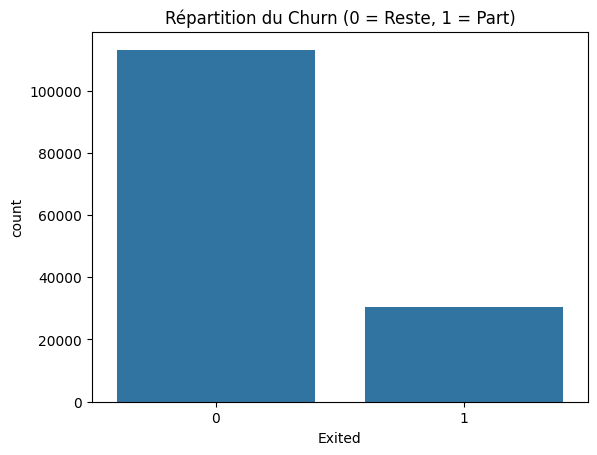

In [13]:
# Distribution de la variable cible (Exited)
sns.countplot(x='Exited', data=train_df)
plt.title('Répartition du Churn (0 = Reste, 1 = Part)')
plt.show()

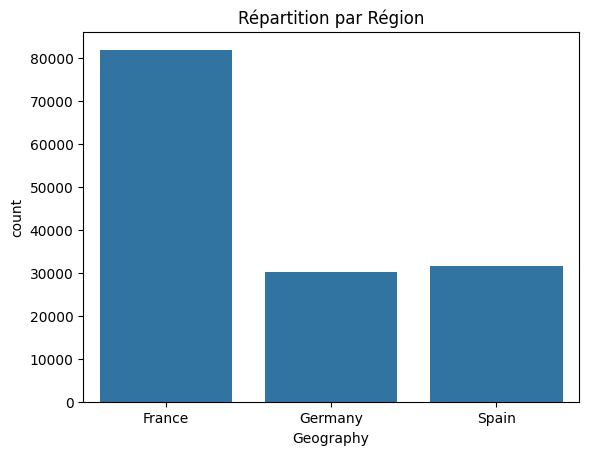

In [14]:
# Distribution de la vvariable geographique (Geography)
sns.countplot(x='Geography', data=train_df)
plt.title('Répartition par Région')
plt.show()


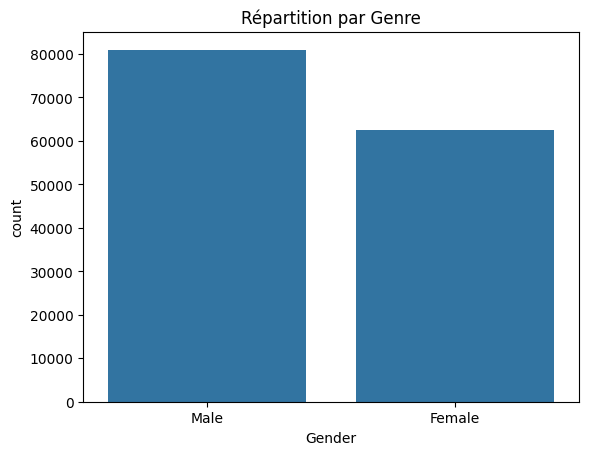

In [15]:
# Distribution de la variable gender
sns.countplot(x='Gender', data=train_df)
plt.title('Répartition par Genre')
plt.show()


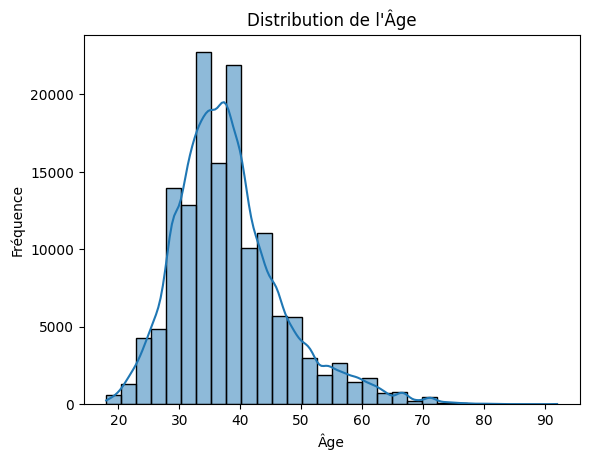

In [16]:
# Distribution de la variable Age
sns.histplot(train_df['Age'], bins=30, kde=True)
plt.title('Distribution de l\'Âge')
plt.xlabel('Âge')
plt.ylabel('Fréquence')
plt.show()

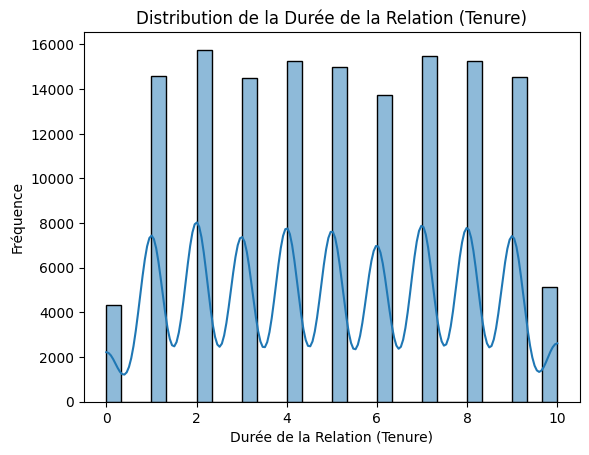

In [17]:
# Distribution de la variable Tenure en années
sns.histplot(train_df['Tenure'], bins=30, kde=True)
plt.title('Distribution de la Durée de la Relation (Tenure)')
plt.xlabel('Durée de la Relation (Tenure)')
plt.ylabel('Fréquence')
plt.show()


### Analyse Discrète-Discrète

Pourcentage de Churn par Genre :
 Exited          0          1
Gender                      
Female  71.930749  28.069251
Male    84.098263  15.901737


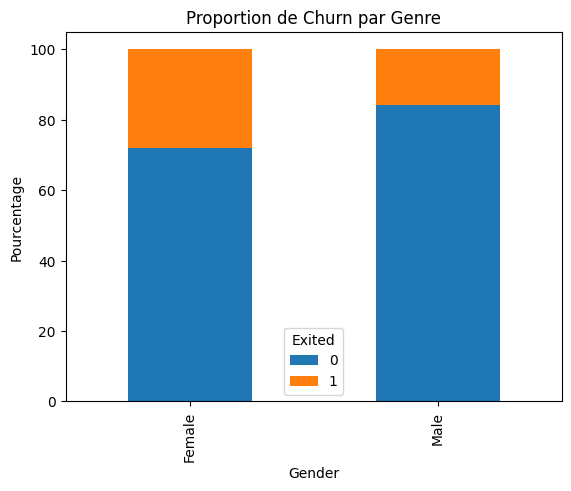

In [19]:
# Relation Genre vs Exited
gender_churn = pd.crosstab(train_df['Gender'], train_df['Exited'], normalize='index') * 100
print("Pourcentage de Churn par Genre :\n", gender_churn)

# Visualisation
gender_churn.plot(kind='bar', stacked=True)
plt.ylabel('Pourcentage')
plt.title('Proportion de Churn par Genre')
plt.show()

Pourcentage de Churn par Région :
 Exited             0          1
Geography                      
France     83.455047  16.544953
Germany    61.973094  38.026906
Spain      82.733950  17.266050


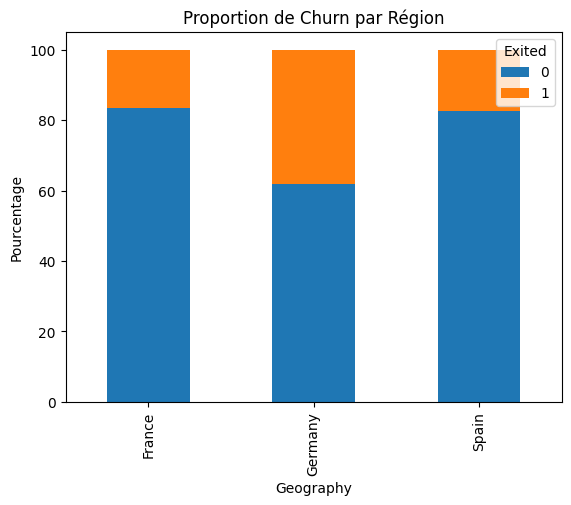

In [20]:
# Relation Geography vs Exited
geography_churn = pd.crosstab(train_df['Geography'], train_df['Exited'], normalize='index') * 100
print("Pourcentage de Churn par Région :\n", geography_churn)

# Visualisation
geography_churn.plot(kind='bar', stacked=True)
plt.ylabel('Pourcentage')
plt.title('Proportion de Churn par Région')
plt.show()

Pourcentage de Churn par Région et Genre :
 Exited                    0          1
Geography Gender                      
France    Female  77.421581  22.578419
          Male    87.909988  12.090012
Germany   Female  53.510304  46.489696
          Male    69.645345  30.354655
Spain     Female  77.310054  22.689946
          Male    86.790991  13.209009


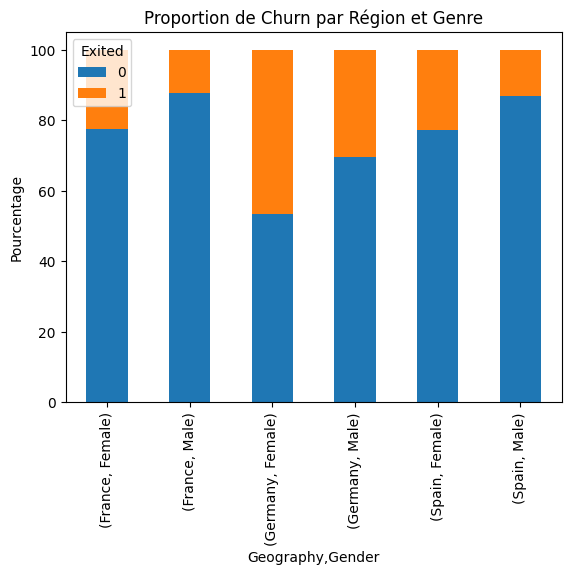

In [22]:
# Relation Geography et Gender vs Exited
geo_gender_churn = pd.crosstab([train_df['Geography'], train_df['Gender']], train_df['Exited'], normalize='index') * 100
print("Pourcentage de Churn par Région et Genre :\n", geo_gender_churn)


# Visualisation
geo_gender_churn.plot(kind='bar', stacked=True)
plt.ylabel('Pourcentage')
plt.title('Proportion de Churn par Région et Genre')
plt.show()


### Analyse Discrète-Continue

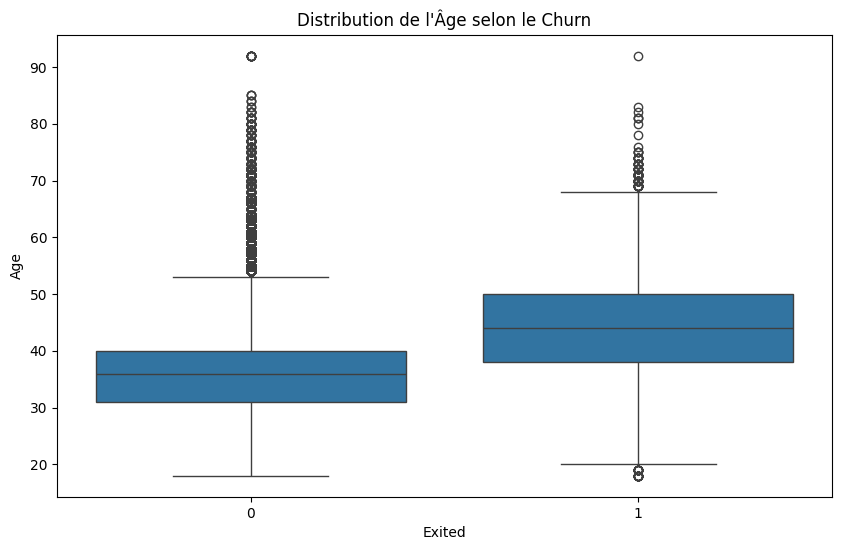

In [24]:
# Relation Age (Continue) vs Exited (Discrète)
plt.figure(figsize=(10,6))
sns.boxplot(x='Exited', y='Age', data=train_df)
plt.title('Distribution de l\'Âge selon le Churn')
plt.show()

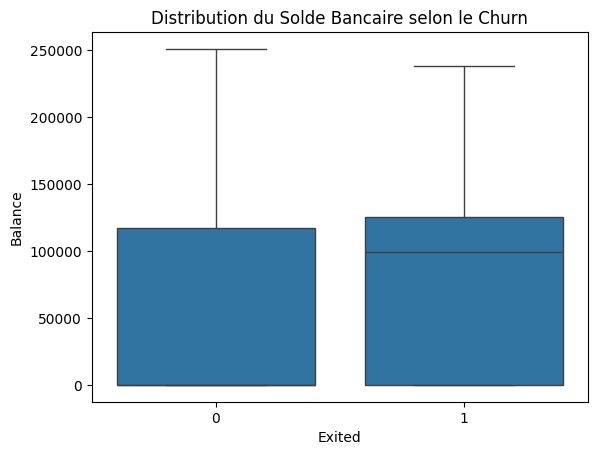

In [26]:
# Relation Solde (Continue) vs Exited (Discrète)
sns.boxplot(x='Exited', y='Balance', data=train_df)
plt.title('Distribution du Solde Bancaire selon le Churn')
plt.show()

### Analyse Continue-Continue

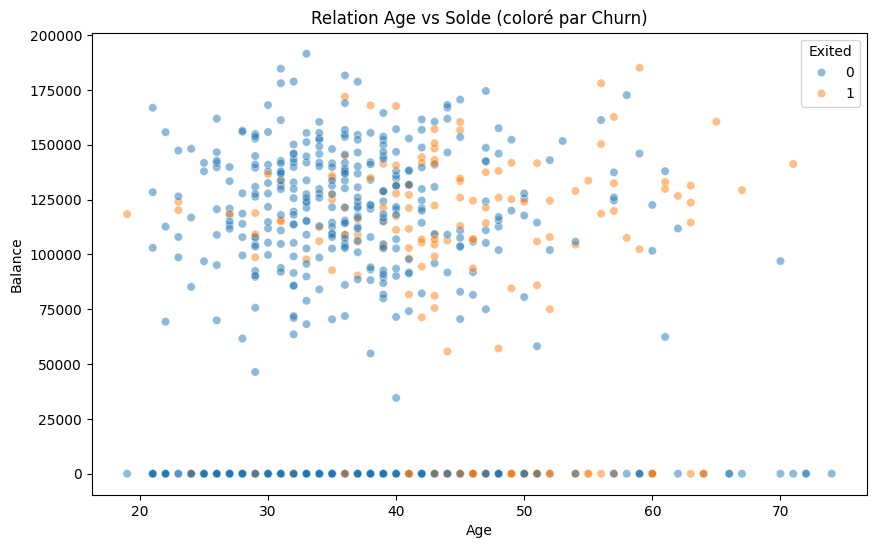

In [27]:
# Relation Age vs Solde
plt.figure(figsize=(10,6))
sns.scatterplot(x='Age', y='Balance', hue='Exited', data=train_df.sample(1000), alpha=0.5)
plt.title('Relation Age vs Solde (coloré par Churn)')
plt.show()